# Initialise tree community for LANDIS-II based on NBI

Last updated: 2026-08-19 <br>
Author: Stefan Vriend

In [3]:
conf_input_location <- "/home/jovyan/Cloud Storage/naa-vre-public/vl-veluwe-forest-model"
conf_tmp_data <- "/tmp/data"

In [21]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load("dplyr", "terra", "sf", "minpack.lm")

Loading required package: pacman



In [5]:
# Veluwe map retriever
#=========================================================
# Load and transform the Natura2000 Veluwe geopackage
natura2000_sf <- sf::read_sf("https://service.pdok.nl/rvo/natura2000/atom/downloads/natura2000.gpkg") |>
sf::st_transform(28992)

# Create the veluwe sf by filtering the Natura2000 shapefile 
veluwe_sf <- natura2000_sf |>
  dplyr::filter(objectid == 4049)

# Load LGN map
# LGN is Landelijk Grondgebruik Nederland, a national map about land use in the Netherlands.
# We use LGN5, which represents land use in 2003-2004 with a 25 meter resolution
# TODO: add option to select other versions of LGN
lgn5 <- terra::rast(file.path(conf_input_location, "LGN5.tif"))

# Turn sf object into vector
veluwe_vect <- terra::vect(veluwe_sf)

# Crop LGN map to Veluwe Natura2000
lgn5_veluwe <- terra::crop(lgn5, veluwe_vect) |>
    terra::mask(veluwe_vect)

# Retain cells that correspond to forest (11, broadleaf forest; 12, coniferous forest)
forest_codes <- c(11, 12)
veluwe_forest <- terra::ifel(lgn5_veluwe %in% forest_codes, 1, NA)

# Save the as geopackage to tmp data so that it can be used in later cells 
#veluwe_datafile <- file.path(conf_tmp_data, "veluwe.gpkg")
#sf::st_write(veluwe_forest, veluwe_datafile, append = FALSE)

In [6]:
# Initial communities data retriever & preprocessor 
#=========================================================
# Download the Microsoft Access database file that contains the most up-to-date data
# from MFV (NBI-5), NBI-6 and NBI-7 from the Probos website 
if (!file.exists(file.path(conf_tmp_data, "NBI.zip"))) {
    url <- "https://probos.nl/DB/NBI-7_openbare_database.zip"
    download.file(url, file.path(conf_tmp_data, "NBI.zip"), mode = "wb")
    unzip(file.path(conf_tmp_data, "NBI.zip"), exdir = conf_tmp_data)
}

# Remove space in unzipped file name
new_file <- file.path(conf_tmp_data, "NBI7_openbare_database_definitief_UpdateJuli2024.accdb")
if (!file.exists(new_file)) {
    file.rename(from = file.path(conf_tmp_data, "NBI7_openbare database_definitief_UpdateJuli2024.accdb"),
                to = new_file)
}
    
# Retrieve the relevant tables from the Microsoft Access database 
# - data_MFV_proefbomen contains measurements on individual sample trees, measurements of which are used to determine volume, biomass and growth of all other trees in a plot
# - data_MFV_boomgegevens contains measurements on individual trees within a plot, such as species and dbh, and estimations of volume, biomass and growth of trees
# - data_MFV_plotdefinitie contains a description of all MFV plots, such as plot id (plotnummer), location, surface area, municipality
# - data_MFV_plotmetingen contains measurements at the MFV plot level, such as sprouting year, soil type, ground water table
data_MFV_proefbomen <- Hmisc::mdb.get(new_file, tables = "data_MFV_proefbomen")
data_MFV_boomgegevens <- Hmisc::mdb.get(new_file, tables = "data_MFV_boomgegevens")
data_MFV_plotdefinitie <- Hmisc::mdb.get(new_file, tables = "data_MFV_plotdefinitie")
data_MFV_plotmetingen <- Hmisc::mdb.get(new_file, tables = "data_MFV_plotmetingen")

# Wrangle Access tables
# - convert diameter columns to cm
# - rename columns to English names and lowercase
# - retain only necessary columns
nbi5_forest_data <- data_MFV_boomgegevens |>
    tibble::as_tibble() |>
    dplyr::mutate(dbh_cm = .data$DIAMETER.MM / 10) |>
    dplyr::select("tree_number" = "BOOMNUMMER", "plot_number" = "PLOTNUMMER", "species_name" = "BOOMSOORT", "species_code" = "CODE.BOOMSOORT", 
                  "basal_area_m2" = "Grondvlak.m2", "dbh_cm", "volume_dm3" = "Volume.m3", "number_of_stems_ha" = "NstamHA", "biomass_stem_kg" = "Stambiomassa.kg", 
                  "biomass_branch_kg" = "Takbiomassa.kg", "biomass_leaf_kg" = "Bladbiomassa.kg", "biomass_root_kg" = "Wortelbiomassa.kg") |>
    type.convert(as.is = TRUE)

nbi5_plot_definition <- data_MFV_plotdefinitie |>
    dplyr::select("plot_number" = "PLOTNUMMER", "grid" = "GRID") |>
    type.convert(as.is = TRUE)

nbi5_plot_measurements <- data_MFV_plotmetingen |>
    dplyr::mutate("plot_size_ha" = .data$Plotoppervlak.totaal.dm2 / 1e06) |>
    dplyr::select("plot_number" = "PLOTNUMMER", "plot_size_ha", "top10_code" = "TOP10CODE", "measurement_date" = "OPNAMEDATUM", 
                  "germination_year" = "KIEMJAAR", "density_ha" = "Stamtal.ha.levend") |>
    type.convert(as.is = TRUE) |>
    dplyr::mutate("measurement_date" = as.Date(.data$measurement_date))

nbi5_sample_trees <- data_MFV_proefbomen |>
    dplyr::mutate("dbh_cm" = .data$DIAMETER.MM / 10) |>
    dplyr::select("plot_number" = "PLOTNUMMER", "species_name" = "BOOMSOORT", "species_code" = "CODE.BOOMSOORT", "height_m" = "HOOGTE.M", "dbh_cm") |>
    type.convert(as.is = TRUE)

## TODO
# 1a. Calculate ages
# 1b. What to do with 'rest' species?
# 2. Aggregate biomass by age class and scale to density

[1] TRUE

25 variables; Processing variable:1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 


In [7]:
# Filter NBI plots that are within the Veluwe
veluwe_plots <- nbi5_plot_definition |> 
    dplyr::mutate("lat" = as.integer(stringr::str_extract(.data$grid, "(?<=N)\\d+")) * 1000 + 500,
                  "lon" = as.integer(stringr::str_extract(.data$grid, "(?<=E)\\d+")) * 1000 + 500) |> 
    sf::st_as_sf(coords = c("lon", "lat"), 
                 crs = 3035) |> 
    sf::st_transform(crs = sf::st_crs(veluwe_forest)) |> 
    {\(.) dplyr::mutate(.,
                        "x" = sf::st_coordinates(.)[,1], 
                        "y" = sf::st_coordinates(.)[,2])}() |>
    terra::vect() |>
    terra::crop(veluwe_forest) |>
    terra::as.data.frame() |>
    dplyr::left_join(nbi5_plot_measurements, by = "plot_number")

# Associate age (based on germination year, kiemjaar) with sample trees
veluwe_sample_trees <- nbi5_sample_trees |> 
  dplyr::right_join(veluwe_plots |> 
                      dplyr::select("plot_number", "measurement_date", "germination_year"),
                    by = "plot_number") |> 
  dplyr::mutate("age" = lubridate::year(.data$measurement_date) - .data$germination_year)

In [8]:
# Create table with parameters for species-specific height growth models, from WUR-FEM reports
height_growth_parameters <- tibble::tribble(
    # ref_age = reference age; c1, c2, c3, c4 are model parameters
    ~"species", ~"ref_age", ~"c1", ~"c2", ~"c3", ~"c4",
    # Jansen et al. 2018a (https://edepot.wur.nl/444090), eq 10; c1, c2, c3 derived from Table 3, page 12
    "pinus sylvestris", 70L, 1.5162, 2500.5706, 22.0801, NA,
    # Jansen et al. 2018b (https://edepot.wur.nl/444089), eq 9; c1, c2, c3 derived from Table 3, page 14
    "picea abies", 50L, 1.7859, 2181.7777, 29.2173, NA,
    # Jansen et al. 2018c (https://edepot.wur.nl/444088), eq 12; c1, c2, c3 derived from Table 3 (North), page 15
    "larix kaempferi", 50L, 1.1565, 1259.1192, 34.2727, NA,
    # Jansen et al. 2018d (https://edepot.wur.nl/444093), eq 10; c1, c2, c3 derived from Table 3, page 11
    "quercus robur", 70L, 1.0690, 1449.4523, 34.2039, NA,
    # Jansen et al. 2018e (https://edepot.wur.nl/444094), eq 12; c1, c2, c3 derived from Table 3, page 14
    "fagus sylvatica", 70L, 1.2165, 5653.0980, 14.2701, NA,
    # Jansen et al. 2019f (https://edepot.wur.nl/444098), eq 7; c1, c2, c3 derived from Table 2, page 9
    "quercus rubra", NA, 0.0199, 5.2936, 0.1462, NA,
    # Jansen et al. 2016 (https://doi.org/10.3920/978-90-8686-827-8), eq 31; c1-c4 derived from Table 7, page 38
    "pseudotsuga menziesii", NA, 0.0278, 3.4405, 0.0557, 1.3872,
    # Jansen et al. 2018g (https://edepot.wur.nl/444102), eq 7; c1, c2, c3 derived from Table 3, page 10
    "betula pendula", 50L, 1.3198, 1065.6372, 16.4603, NA
)

# Create function to calculate height based on species, age (t) and the site index (boniteit)
calculate_height <- function(species, site_index, t) {

    # Get species-specific model parameters
    pars <- height_growth_parameters |> dplyr::filter(.data$species == {{species}})
    c1 <- pars$c1
    c2 <- pars$c2
    c3 <- pars$c3
    c4 <- pars$c4
    ref_age <- pars$ref_age

    if(species == "quercus rubra" ) {

        b <- c2 - c3 * site_index
        h_top <- site_index * (1 - exp(-c1 * t))^b

    } else if(species == "pseudotsuga menziesii") {

            b <- c2 - c3 * site_index
            t7 <- -log(1-(7 / site_index)^(1 / b)) / c1
            ak <- (c1 * b * (site_index / 7) * exp(-c1 * t7) * (1 - exp(-c1 * t7))^(b-1)) / (c4 * t7^(-c4 - 1))

            h_top <- dplyr::if_else(t <= t7, 
                                    7 * (exp(-ak * t^(-c4))) / (exp(-ak * t7^(-c4))),
                                    site_index * (1 - exp(-c1 * t))^b)
                               
    } else {

        Z <- site_index - c3
        R <- Z + sqrt(Z^2 + (2 * c2 * site_index) / (ref_age^c1))
        h_top <- site_index * ((t^c1) * ((ref_age^c1) * R + c2)) / ((ref_age^c1) * ((t^c1) * R + c2))
        
    }

    h_top
    
}

# Nonlinear least squares approach to finding the species-specific site indices for the Veluwe
find_site_index <- function(data, species, start, ...) {

    pars <- height_growth_parameters |> dplyr::filter(.data$species == {{species}})
    c1 <- pars$c1
    c2 <- pars$c2
    c3 <- pars$c3
    c4 <- pars$c4
    ref_age <- pars$ref_age

    # NB: For finding the site index, we use a simpler model for 'pseudotsuga menziesii' because the two-step model by Jansen et al. 2016 is too complicated to optimise
    # i.e., we use the logistic growth model for the full range of ages instead of only for the ages when height > 7 meters
    if(species %in% c("quercus rubra", "pseudotsuga menziesii")) {
        
        mod <- nls(height ~ site_index * (1 - exp(-c1 * t))^(c2 - c3 * site_index), 
                   data = data, start = start, ...)
        
    } else {

        mod <- nls(height ~ site_index * ((t^c1) * ((ref_age^c1) * ((site_index - c3) + sqrt((site_index - c3)^2 + (2 * c2 * site_index) / (ref_age^c1))) + c2)) / ((ref_age^c1) * ((t^c1) * ((site_index - c3) + sqrt((site_index - c3)^2 + (2 * c2 * site_index) / (ref_age^c1))) + c2)),
                   data = data, start = start, ...)
    }
    
    return(mod)
    
}

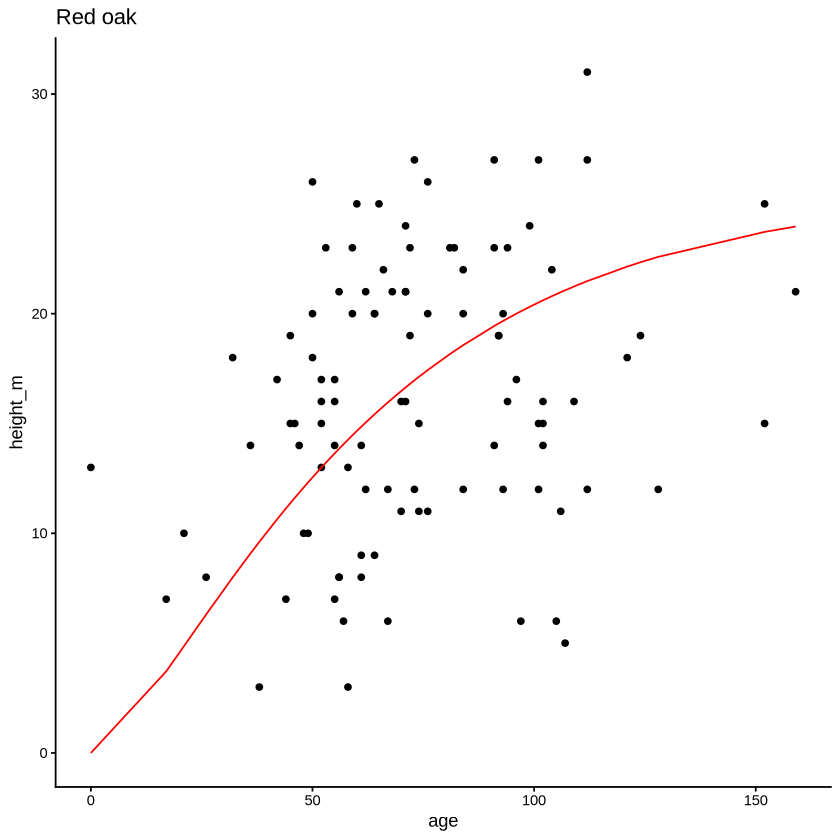

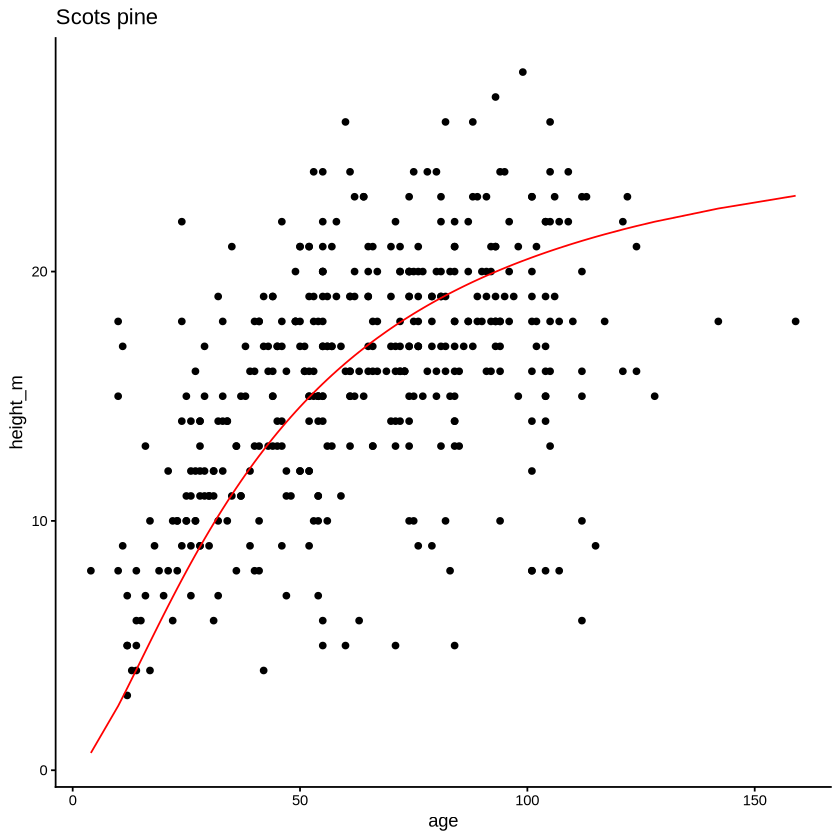

In [9]:
# Two examples, for Red Oak and Scots Pine
a <- find_site_index(data = veluwe_sample_trees |> dplyr::filter(.data$species_name == "Amerikaanse eik") |> dplyr::select("height" = "height_m", "t" = "age"),
                     species = "quercus rubra", start = list(site_index = 25))

b <- find_site_index(data = veluwe_sample_trees |> dplyr::filter(.data$species_name == "Grove den") |> dplyr::select("height" = "height_m", "t" = "age"),
                     species = "pinus sylvestris", start = list(site_index = 25))

veluwe_sample_trees |> 
  dplyr::filter(.data$species_name == "Amerikaanse eik") |>
  dplyr::mutate(htop = calculate_height("quercus rubra", site_index = coefficients(a), age)) |> 
  ggplot2::ggplot() +
  ggplot2::geom_point(mapping = ggplot2::aes(x = age, y = height_m)) +
  ggplot2::geom_line(mapping = ggplot2::aes(x = age, y = htop), color = "red") +
  ggplot2::labs(title = "Red oak") + 
  ggplot2::theme_classic()

veluwe_sample_trees |> 
  dplyr::filter(.data$species_name == "Grove den") |>
  dplyr::mutate(htop = calculate_height("pinus sylvestris", site_index = coefficients(b), age)) |> 
  ggplot2::ggplot() +
  ggplot2::geom_point(mapping = ggplot2::aes(x = age, y = height_m)) +
  ggplot2::geom_line(mapping = ggplot2::aes(x = age, y = htop), color = "red") +
  ggplot2::labs(title = "Scots pine") + 
  ggplot2::theme_classic()

In [10]:
# Find age for given height
find_age <- function(height, species, site_index, lower = 0, upper = 200) {

    a <- species
    b <- site_index

    sapply(height, function(height) uniroot(function(x) calculate_height(species = a, site_index = b, x) - height, 
                                            lower = lower, upper = upper)$root)
    
} 

find_age(20, species = "pinus sylvestris", site_index = 17.72)

[1] 93.13224

In [ ]:
# We need to use these yield tables
# because we do not have height for most trees, only dbh

scots_pine_boni <-
  tibble::tibble(
    boniteit = c("I", "II", "III", "IV", "V"),
    h70 = c(23.8, 20.8, 17.8, 14.8, 11.8)
  )

scots_pine <- tibble::tibble(
  boniteit = "I",
  t = seq(5, 150, by = 5),
  d = c(1.3, 5.2, 8.1, 9.6, 12.3, 14.8, 17.1, 19.1, 21, 22.8, 24.4, 26.1, 27.8,
        29.3, 30.8, 32.2, 33.6, 34.8, 36.3, 37.8, 39.3, 40.7, 42.2, 43.6,
        44.9, 46.3, 47.7, 49, 50.4, 51.7),
  h = c(1.6, 4.3, 7.2, 9.9, 12.3, 14.4, 16.1, 17.6, 18.8, 19.9, 20.8,
        21.6, 22.3, 22.9, 23.4, 23.9, 24.3, 24.7, 25, 25.4, 25.7,
        25.9, 26.2, 26.4, 26.6, 26.8, 27, 27.2, 27.4, 27.5)
) |> 
  dplyr::add_row(
    boniteit = "II",
    t = seq(5, 150, by = 5),
    d = c(0.3, 3.5, 6.4, 8.3, 9.8, 12, 14, 15.9, 17.6, 19.2, 20.6, 22.2,
          23.8, 25.3, 26.7, 28, 29.3, 30.5, 31.9, 33.3, 34.6, 36,
          37.3, 38.6, 39.9, 41.2, 42.5, 43.8, 45, 46.3),
    h = c(1.1, 3, 5.3, 7.5, 9.5, 11.4, 13, 14.4, 15.7, 16.7, 17.7, 18.5,
          19.2, 19.9, 20.5, 21, 21.4, 21.9, 22.3, 22.6, 22.9, 23.2,
          23.5, 23.8, 24, 24.2, 24.4, 24.6, 24.8, 25)
  ) |> 
  dplyr::add_row(
    boniteit = "III",
    t = seq(5, 150, by = 5),
    d = c(NA, 2.1, 4.4, 6.5, 8.1, 9.2, 11, 12.7, 14.2, 15.7, 17, 18.5, 
          19.9, 21.3, 22.6, 23.8, 25, 26.2, 27.5, 28.8, 30, 31.3, 32.5,
          33.8, 35, 36.2, 37.4, 38.6, 39.8, 40.9),
    h = c(NA, 2.1, 3.7, 5.4, 7.1, 8.6, 10.1, 11.4, 12.6, 13.6, 14.6,
          15.4, 16.2, 16.9, 17.5, 18.1, 18.6, 19, 19.5, 19.9, 20.2, 20.6,
          20.9, 21.2, 21.4, 21.7, 21.9, 22.2, 22.4, 22.6)
  ) |> 
  dplyr::add_row(
    boniteit = "IV",
    t = seq(5, 150, by = 5),
    d = c(NA, 0.9, 2.8, 4.5, 6, 7.5, 8.5, 9.6, 11, 12.3, 13.6, 14.9,
          16.2, 17.4, 18.6, 19.7, 20.9, 21.9, 23.1, 24.3, 25.5, 26.6,
          27.8, 29, 30.1, 31.2, 32.4, 33.5, 34.6, 35.7),
    h = c(NA, 1.4, 2.5, 3.7, 5, 6.3, 7.5, 8.6, 9.7, 10.6, 11.6, 12.4,
          13.2, 13.9, 14.5, 15.1, 15.7, 16.2, 16.7, 17.1, 17.5, 17.9,
          18.2, 18.6, 18.9, 19.2, 19.5, 19.7, 20, 20.2)
  ) |> 
  dplyr::add_row(
    boniteit = "V",
    t = seq(5, 150, by = 5),
    d = c(NA, NA, 1.3, 2.7, 4, 5.2, 6.3, 7.3, 8.2, 9, 10.1, 11.3, 12.6,
          13.7, 14.8, 15.9, 16.9, 17.8, 18.9, 19.9, 21, 22.1, 23.1,
          24.2, 25.2, 26.3, 27.3, 28.4, 29.4, 30.5),
    h = c(NA, NA, 1.6, 2.5, 3.4, 4.3, 5.3, 6.2, 7.1, 7.9, 8.7, 9.5,
          10.2, 10.9, 11.5, 12.1, 12.7, 13.2, 13.7, 14.2, 14.6, 15.1, 
          15.5, 15.8, 16.2, 16.5, 16.8, 17.1, 17.4, 17.7)
  ) |> 
  dplyr::left_join(scots_pine_boni, by = "boniteit")

boni <- scots_pine_boni |> 
  dplyr::mutate(dif = coefficients(b) - h70) |> 
  dplyr::filter(dif > 0) |> 
  dplyr::filter(dif == min(dif)) |> 
  dplyr::pull(boniteit)

In [11]:
# Calculate goodness-of-fit metrics
# Coefficient of determination
pseudo_r2 <- function(x, mod) {

    ss_res <- sum((x - fitted(mod))^2) # residual sum of squares
    ss_tot <- sum((x - mean(x))^2) # total sum of squares

    1 - (ss_res / ss_tot) # pseudo coefficient of determination
    
}

# Root mean squared error
rmse <- function(x, mod) {

    sqrt(mean((x - fitted(mod))^2)) # root mean squared error
    
}

[1] 0.7034748 0.6990830 0.6986392

[1] 10.70497 10.78395 10.79190

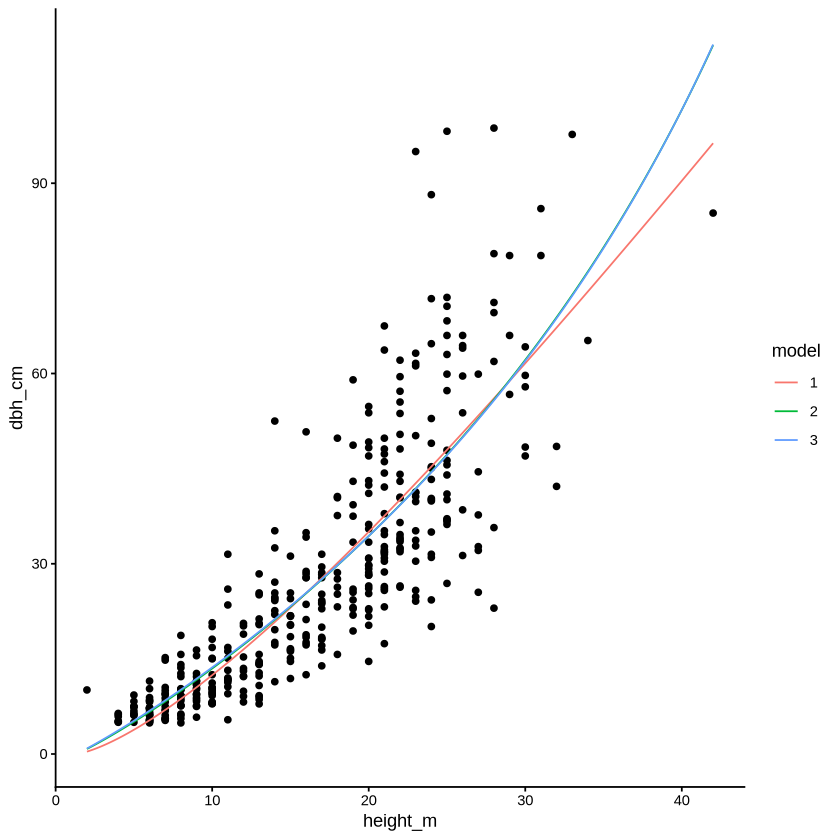

In [52]:
# DBH prediction from tree height, following Bi et al. 2012 Canadian Journal of Forest Research, https://doi.org/10.1139/x2012-019
# 3 models came out best:
# - 1: combined power + exponential model
# - 2: inverse Richards
# - 3: inverse Weibull

selected_species <- "Beuk"
selected_data <- nbi5_sample_trees |> dplyr::filter(species_name == selected_species)

# Linearise model 1 to find starting values
lin_mod <- lm(log(dbh_cm) ~ log(height_m) + height_m, data = selected_data)
start <- list(a = exp(coef(lin_mod)[1]), b = coef(lin_mod)[2], c = coef(lin_mod)[3])
                                                                                                        
dmod1 <- minpack.lm::nlsLM(dbh_cm ~ a * (height_m - 1.3)^b * exp(c * (height_m - 1.3)), data = selected_data, start = start, control = list(maxiter = 1000))
dmod2 <- minpack.lm::nlsLM(dbh_cm ~ -b^-1 * log(1 - ((height_m - 1.3) / 60) ^ (1/c)), data = selected_data, start = list(b = 0.001, c = 0.25), control = list(maxiter = 1000))
dmod3 <- minpack.lm::nlsLM(dbh_cm ~ (-b^-1 * log(1 - ((height_m - 1.3) / 60))) ^ (1/c), data = selected_data, start = list(b = 0.001, c = 0.25), control = list(maxiter = 1000))

dummy_height <- seq(min(selected_data$height_m), max(selected_data$height_m), length.out = 1000)
dbh_mods <- list(dmod1, dmod2, dmod3)

dmod_pred <- tibble::tibble(
    height = rep(dummy_height, length(dbh_mods)),
    dbh = c(predict(dmod1, list(height_m = dummy_height)), predict(dmod2, list(height_m = dummy_height)), predict(dmod3, list(height_m = dummy_height))),
    model = rep(as.character(seq_len(length(dbh_mods))), each = 1000)
)

ggplot2::ggplot() + 
    ggplot2::geom_point(data = selected_data, mapping = ggplot2::aes(x = height_m, y = dbh_cm)) +
    ggplot2::geom_line(data = dmod_pred, mapping = ggplot2::aes(x = height, y = dbh, color = model, group = model)) + 
    ggplot2::theme_classic()

sapply(dbh_mods, \(.) pseudo_r2(selected_data |> dplyr::pull(dbh_cm), .))
sapply(dbh_mods, \(.) rmse(selected_data |> dplyr::pull(dbh_cm), .))

[1] 0.7645955 0.8000343 0.7996150

[1] 3.515744 3.240318 3.243713

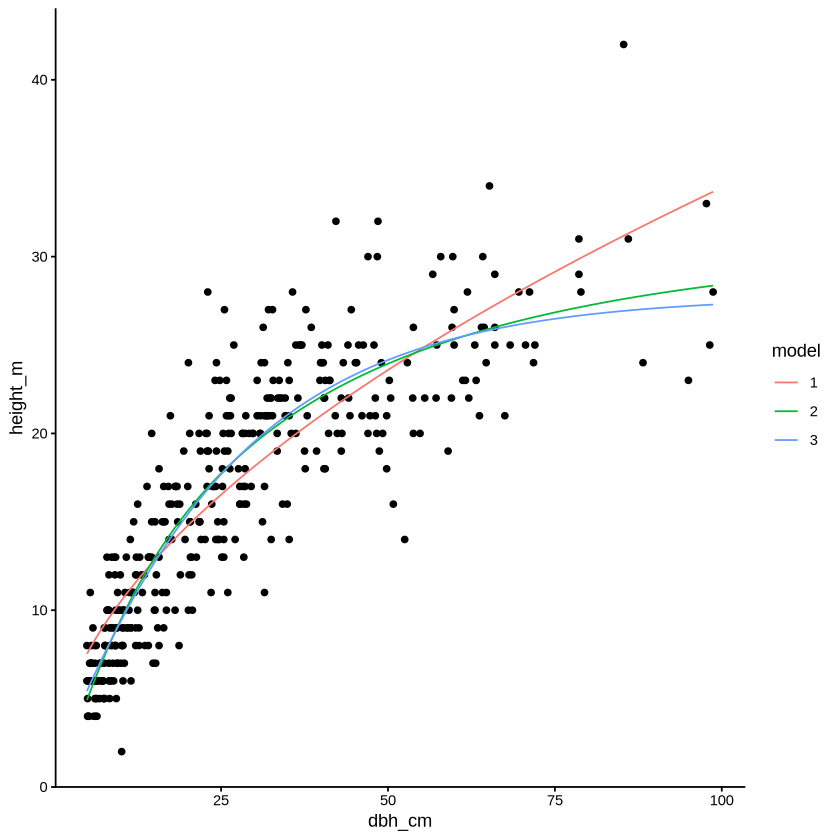

In [37]:
# Height prediction from dbh, following West & Strimbu, 2025, Forestry: An International Journal of Forest Research, https://doi.org/10.1093/forestry/cpaf010
# - 1: power model
# - 2: Sibbesen model
# - 3: Chapman-Richards model

lin_mod <- lm(log10(height_m) ~ log10(dbh_cm), data = selected_data)
start1 <- list(a = 10 ^ coef(lin_mod)[1], b = coef(lin_mod)[2])
mod1 <- minpack.lm::nlsLM(height_m ~ 1.3 + a * dbh_cm ^ b, data = selected_data, start = start1, control = list(maxiter = 1000))

start2 <- list(a = 10 ^ coef(lin_mod)[1], b = coef(lin_mod)[2], c = log10(coef(lin_mod)[2]))
mod2 <- minpack.lm::nlsLM(height_m ~ 1.3 + a * dbh_cm ^ (b * dbh_cm ^ c), data = selected_data, start = start2, control = list(maxiter = 1000))

lin_mod_lm <- lm(log(height_m) ~ log(dbh_cm), data = selected_data)
start3 <- list(a = exp(coef(lin_mod_lm)[1]), b = log(coef(lin_mod_lm)[2]), c = coef(lin_mod_lm)[2])
mod3 <- minpack.lm::nlsLM(height_m ~ 1.3 + a * (1 - exp(b * dbh_cm)) ^ c, data = selected_data, start = start3, control = list(maxiter = 1000))

height_mods <- list(mod1, mod2, mod3)
dummy_dbh <- seq(min(selected_data$dbh_cm), max(selected_data$dbh_cm), length.out = 1000)

hmod_pred <- tibble::tibble(
    dbh = rep(dummy_dbh, length(height_mods)),
    height = unlist(lapply(height_mods, \(.) predict(., list(dbh_cm = dummy_dbh)))),
    model = rep(as.character(seq_len(length(height_mods))), each = 1000)
)

ggplot2::ggplot() + 
    ggplot2::geom_point(data = selected_data, mapping = ggplot2::aes(x = dbh_cm, y = height_m)) +
    ggplot2::geom_line(data = hmod_pred, mapping = ggplot2::aes(x = dbh, y = height, color = model, group = model)) + 
    ggplot2::theme_classic()

sapply(height_mods, \(.) pseudo_r2(selected_data |> dplyr::pull(height_m), .))
sapply(height_mods, \(.) rmse(selected_data |> dplyr::pull(height_m), .))